# Convnet 1D

El analizis de datos temporales tambien se puede realizar con convoluciones de una dimension. 

El metodo convolucional resulta adecuado para hallar patrones temporales debido a que, similar a los problemas de vision por computadora, se puede realizar una captura jerarquica de caracteristicas.

Para problemas sencillos es deseable usarlas ya que entrenan mas rapido.

# Conjunto de datos IMDb

Para introducir la arquitectura se emplea el problema IMDb de clasificacion de sentimientos.

In [1]:
from keras.datasets import imdb
from keras.preprocessing import sequence

max_features = 1000
max_len = 500

print('Loading data...')
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)
print(len(x_train), 'train sequences')
print(len(x_test), 'test sequences')

print('Pad sequences (sample x time)')
x_train = sequence.pad_sequences(x_train, maxlen=max_len)
x_test = sequence.pad_sequences(x_test, maxlen=max_len)
print('x_train_shape: ', x_train.shape)
print('x_test_shape: ', x_test.shape)

2026-01-11 18:46:40.028872: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768168000.537753  158122 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768168000.676640  158122 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768168001.936502  158122 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768168001.936572  158122 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768168001.936581  158122 computation_placer.cc:177] computation placer alr

Loading data...
25000 train sequences
25000 test sequences
Pad sequences (sample x time)
x_train_shape:  (25000, 500)
x_test_shape:  (25000, 500)


# Caso practico Convnet 1D

A continuacion se muestra un **ejemplo** de una **Convnet 1D**.

In [5]:
from keras.models import Sequential
from keras.layers import Conv1D, MaxPool1D, Embedding, GlobalMaxPool1D, Dense
from keras.optimizers import RMSprop
from keras.losses import BinaryCrossentropy

model = Sequential()
model.add(Embedding(max_features, 128, input_shape=(max_len,)))
model.add(Conv1D(32, 7, activation='relu'))
model.add(MaxPool1D(5))
model.add(Conv1D(32, 7, activation='relu'))
model.add(GlobalMaxPool1D())
model.add(Dense(1))

model.summary()

model.compile(optimizer=RMSprop(),
              loss=BinaryCrossentropy(from_logits=True),
              metrics=['acc'])

history = model.fit(x_train, y_train,
                    epochs=30,
                    batch_size=128,
                    validation_split=0.2)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 500, 128)       │       128,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 494, 32)        │        28,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 98, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 92, 32)         │         7,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ (None, 32)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 163,937 (640.38 KB)

 Trainable params: 163,937 (640.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 117ms/step - acc: 0.5154 - loss: 0.6681 - val_acc: 0.7736 - val_loss: 0.4539
Epoch 2/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - acc: 0.7767 - loss: 0.4426 - val_acc: 0.7682 - val_loss: 0.4146
Epoch 3/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - acc: 0.8399 - loss: 0.3477 - val_acc: 0.8458 - val_loss: 0.3484
Epoch 4/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - acc: 0.8567 - loss: 0.3215 - val_acc: 0.8526 - val_loss: 0.3432
Epoch 5/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - acc: 0.8794 - loss: 0.2795 - val_acc: 0.8002 - val_loss: 0.3828
Epoch 6/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - acc: 0.8880 - loss: 0.2612 - val_acc: 0.8436 - val_loss: 0.3461
Epoch 7/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - acc: 0.9057 - loss: 0.2262 - val_acc: 0.8600 - val_loss: 0.3386
Epoch 8/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - acc: 0.9170 - loss: 0.2029 - val_acc: 0.7924 - val_loss: 0.4497
Epoch 9/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 37m

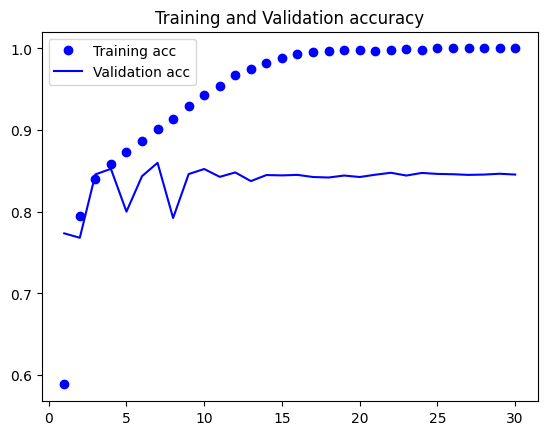

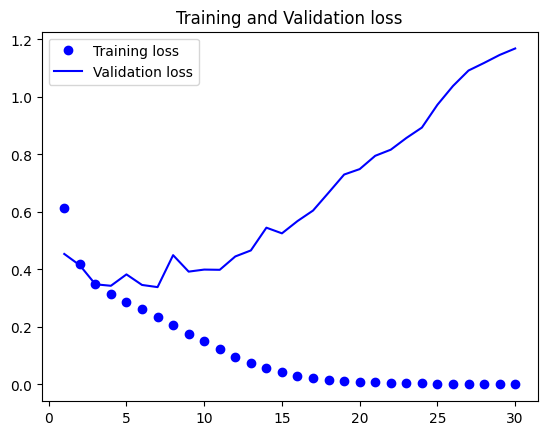

In [6]:
import matplotlib.pyplot as plt

acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc)+1)

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and Validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and Validation loss')
plt.legend()

plt.show()

Equipara el rendimiento de **0.86** **de LSTM** en mucho **menos tiempo**.

Se va a reentrenar la red con 8 epocas para optimizar el rendimineto.

In [7]:
from keras.models import Sequential
from keras.layers import Conv1D, MaxPool1D, Embedding, GlobalMaxPool1D, Dense
from keras.optimizers import RMSprop
from keras.losses import BinaryCrossentropy

model = Sequential()
model.add(Embedding(max_features, 128, input_shape=(max_len,)))
model.add(Conv1D(32, 7, activation='relu'))
model.add(MaxPool1D(5))
model.add(Conv1D(32, 7, activation='relu'))
model.add(GlobalMaxPool1D())
model.add(Dense(1))

model.summary()

model.compile(optimizer=RMSprop(),
              loss=BinaryCrossentropy(from_logits=True),
              metrics=['acc'])

history = model.fit(x_train, y_train,
                    epochs=8,
                    batch_size=128,
                    validation_split=0.2)

/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 500, 128)       │       128,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 494, 32)        │        28,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 98, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 92, 32)         │         7,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_3          │ (None, 32)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 163,937 (640.38 KB)

 Trainable params: 163,937 (640.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 91ms/step - acc: 0.5226 - loss: 0.6710 - val_acc: 0.7958 - val_loss: 0.4674
Epoch 2/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - acc: 0.7854 - loss: 0.4443 - val_acc: 0.7546 - val_loss: 0.4367
Epoch 3/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - acc: 0.8356 - loss: 0.3593 - val_acc: 0.8016 - val_loss: 0.3801
Epoch 4/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - acc: 0.8547 - loss: 0.3231 - val_acc: 0.8488 - val_loss: 0.3427
Epoch 5/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - acc: 0.8692 - loss: 0.2922 - val_acc: 0.8506 - val_loss: 0.3369
Epoch 6/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - acc: 0.8828 - loss: 0.2715 - val_acc: 0.8490 - val_loss: 0.3387
Epoch 7/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - acc: 0.8972 - loss: 0.2392 - val_acc: 0.8494 - val_loss: 0.3771
Epoch 8/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - acc: 0.9112 - loss: 0.2158 - val_acc: 0.8472 - val_loss: 0.3478


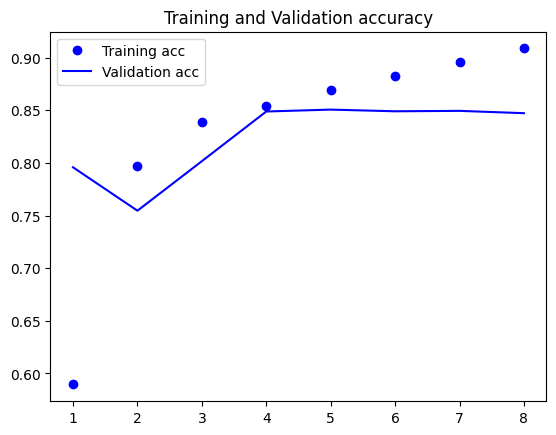

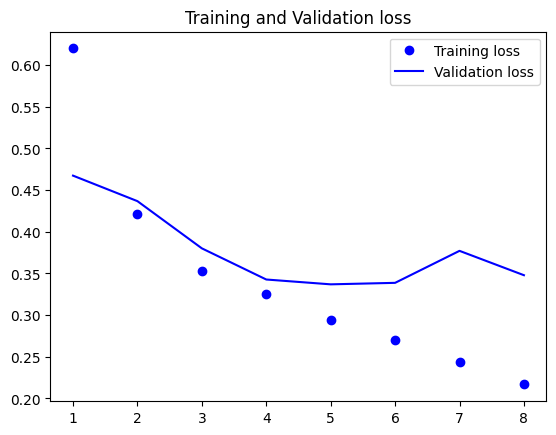

In [9]:
import matplotlib.pyplot as plt

acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc)+1)

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and Validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and Validation loss')
plt.legend()

plt.show()

# Prediccion de clima con Convnet 1D

Se pueden lograr capas que ven grandes porciones de los datos originales  apilando varias capas de convolucion y de agrupacion. No obstante esta es una forma debil de inducir sensibilidad al orden.

Lo anterior se evidencia con el problema de prediccion de temperatura, a continuacion se declara lo necesario para usar el conjunto de datos.

## Conjunto de datos de clima de Jena

In [1]:
import os

data_dir = 'datasets/jena_climate'
fname = os.path.join(data_dir, 'jena_climate_2009_2016.csv')

f = open(fname)
data = f.read()
f.close()

lines = data.split('\n')
header = lines[0].split(',')
lines = lines[1:]

print(header)
print(len(lines))

['"Date Time"', '"p (mbar)"', '"T (degC)"', '"Tpot (K)"', '"Tdew (degC)"', '"rh (%)"', '"VPmax (mbar)"', '"VPact (mbar)"', '"VPdef (mbar)"', '"sh (g/kg)"', '"H2OC (mmol/mol)"', '"rho (g/m**3)"', '"wv (m/s)"', '"max. wv (m/s)"', '"wd (deg)"']
420451


In [2]:
import numpy as np

float_data = np.zeros((len(lines), len(header)-1))
for i, line in enumerate(lines):
    values = [float(x) for x in line.split(',')[1:]]    # Se elimina la columna 'Date Time'
    float_data[i,:] = values

Se preprocesan y se preparan los generadores de lotes.

In [3]:
mean = float_data[:200000].mean(axis=0)
float_data -= mean
std = float_data[:200000].std(axis=0)
float_data /= std

In [4]:
"""_sumary_
Params:
- data: conjunto de datos.
- lookback: cuantos timesteps atras hay que considerar.
- delay: cuantos timesteps a futuro esta el objetivo.
- min_index: limite inferior de los datos a considerar.
- max_index: limite superior de los datos a considerar.
- shuffle: proveer datos en orden cronologico o no.
- batch_size: tamaño de lote.
- step: cada cuantos timeteps devolver informacion.
"""
from keras.utils import Sequence
import numpy as np
import math

class JenaClimateSequence(Sequence):

  def __init__(self, data, lookback, delay, min_index, max_index,
                 batch_size=128, step=6, shuffle=False):
    self.data = data
    self.lookback = lookback
    self.delay = delay
    self.min_index = min_index
    self.max_index = max_index if max_index is not None else len(data) - delay - 1
    self.batch_size = batch_size
    self.step = step
    self.shuffle = shuffle
    self.indices = np.arange(self.min_index, self.max_index)
    self.i = min_index + lookback

  # Number of batch in the Sequence.
  def __len__(self):
    #return math.ceil((self.max_index - (self.min_index + self.lookback)) / self.batch_size)
    return 500

  # Gets batch at position index
  def __getitem__(self, idx):
    if self.shuffle:
      rows = np.random.randint(
        self.min_index + self.lookback, self.max_index, size=self.batch_size
      )
    else:
      if self.i + self.batch_size + self.delay >= self.max_index:
        #print("⚠️ Reiniciar:", i, min_index, max_index)
        self.i = self.min_index + self.lookback
      rows = np.arange(self.i, min(self.i+self.batch_size, self.max_index - self.delay))
      self.i += len(rows)

    samples = np.zeros((len(rows), self.lookback // self.step, self.data.shape[-1]))
    targets = np.zeros((len(rows),))
    for j, row in enumerate(rows):
      indices = range(row - self.lookback, row, self.step)
      samples[j] = self.data[indices]
      targets[j] = self.data[row + self.delay][1]

    return samples, targets

2026-02-01 18:01:38.017168: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769979698.034784 1898797 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769979698.040263 1898797 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769979698.054423 1898797 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769979698.054440 1898797 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769979698.054442 1898797 computation_placer.cc:177] computation placer alr

In [5]:
lookback = 1440     # 5 dias
step = 6            # 1 x hora
delay = 144         # 24hs adelante
batch_size = 128

train_gen = JenaClimateSequence(
    float_data,
    lookback=lookback,
    delay=delay,
    min_index=0,
    max_index=200000,
    shuffle=True,
    step=step,
    batch_size=batch_size
)

val_gen = JenaClimateSequence(
    float_data,
    lookback=lookback,
    delay=delay,
    min_index=200001,
    max_index=300000,
    step=step,
    batch_size=batch_size
)

test_gen = JenaClimateSequence(
    float_data,
    lookback=lookback,
    delay=delay,
    min_index=300001,
    max_index=None,
    step=step,
    batch_size=batch_size
)

# timesteps considerados dentro de val
val_steps = (300000 - 200001 - lookback) 

# timesteps considerados dentro de test
test_steps = (len(float_data) - 300001 - lookback)

print(f"val_steps {val_steps}, test_steps {test_steps}")

val_steps 98559, test_steps 119010


## CNN

Se entrena el modelo.

In [10]:
from keras.models import Sequential
from keras.layers import Dense, Conv1D, MaxPooling1D, GlobalMaxPool1D
from keras.optimizers import RMSprop

model = Sequential()
model.add(Conv1D(32, 5, activation='relu', input_shape=(None,float_data.shape[-1])))
model.add(MaxPooling1D(3))
model.add(Conv1D(32, 5, activation='relu'))
model.add(MaxPooling1D(3))
model.add(Conv1D(32, 5, activation='relu'))
model.add(GlobalMaxPool1D())
model.add(Dense(1))

model.compile(optimizer=RMSprop(), loss='mae')

history = model.fit(
    train_gen,
    steps_per_epoch=500,
    epochs=20,
    validation_data=val_gen,
    validation_steps=val_steps
)

Epoch 1/20


/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1769980732.157535 1903597 service.cc:152] XLA service 0x7f8ebc009b30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1769980732.157554 1903597 service.cc:160]   StreamExecutor device (0): NVIDIA TITAN X (Pascal), Compute Capability 6.1
2026-02-01 18:18:52.247598: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1769980732.406591 1903597 cuda_dnn.cc:529] Loaded cuDNN version 90300


 25/500 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.6037

I0000 00:00:1769980734.397791 1903597 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.4537 - val_loss: 0.4785
Epoch 2/20
 27/500 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3782

/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.3660 - val_loss: 0.4557
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.3393 - val_loss: 0.4468
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.3253 - val_loss: 0.4163
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.3090 - val_loss: 0.4332
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2978 - val_loss: 0.4390
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2920 - val_loss: 0.4444
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2853 - val_loss: 0.4233
Epoch 9/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2797 - val_loss: 0.4492
Epoch 10/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2749 - val_loss: 0.4553
Epoch 11/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2697 - val_loss: 0.4575
Epoch 12/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2621 - val_loss: 0.4526
Epoch 13/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/s

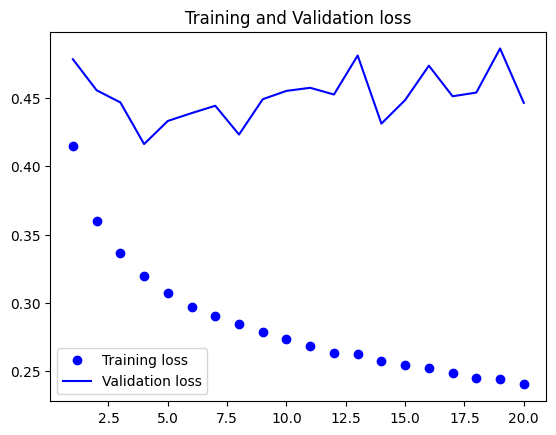

In [11]:
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss)+1)

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and Validation loss')
plt.legend()

plt.show()

La red entrena muchisimo mas rapido que con la version recurrente (1''30'''). No obstante el rendimiento es $>0.40$. Error claramente superior a la linea base.

Las CNN estudian ventanas de datos sin tener conocimiento de la posicion temporal de estos. Esto claramente es perjudicial si se considera que en problemas como el clima los datos pierden relevancia a mas viejos son.

## CNN + RNN

CNN pierde la informacion temporal. RNN tarda mucho en entrenar. Se puede codificar un modelo hibrido que saque lo mejor de ambos mundos.

Usar CNN para recodificar las secuencias largas en secuencias cortas y usar las secuencias cortas como entradas de una RNN. Al contemplar secuencias cortas el tiempo de entrenamiento no sera tan extenso.

Se usa la CNN como un extractor | recodificador de caracteristicas. Similar al uso de *Embeddings*.

![Como funciona una BRNN](images/6.4.cnn+rnn.png)

Esta estrategia **tolera el ingreso de secuencias** mucho **mas grandes de datos**.

A continuacion se redefinen los generadores para que cada timestep capture el doble de datos.

In [12]:
step = 3            # 1 x 30''
loopback = 720      # 5 dias
delay = 144         # 24hs adelante
batch_size = 128

train_gen = JenaClimateSequence(
    float_data,
    lookback=lookback,
    delay=delay,
    min_index=0,
    max_index=200000,
    shuffle=True,
    step=step,
    batch_size=batch_size
)

val_gen = JenaClimateSequence(
    float_data,
    lookback=lookback,
    delay=delay,
    min_index=200001,
    max_index=300000,
    step=step,
    batch_size=batch_size
)

test_gen = JenaClimateSequence(
    float_data,
    lookback=lookback,
    delay=delay,
    min_index=300001,
    max_index=None,
    step=step,
    batch_size=batch_size
)

# timesteps considerados dentro de val
val_steps = (300000 - 200001 - lookback) 

# timesteps considerados dentro de test
test_steps = (len(float_data) - 300001 - lookback)

print(f"val_steps {val_steps}, test_steps {test_steps}")

val_steps 98559, test_steps 119010


A continuacion se define el modelo CNN+RNN (GRU).

In [15]:
from keras.models import Sequential
from keras.layers import Dense, MaxPooling1D, Conv1D, GRU
from keras.optimizers import RMSprop

model = Sequential()
model.add(Conv1D(32, 5, activation='relu', input_shape=(None,float_data.shape[-1])))
model.add(MaxPooling1D(3))
model.add(GRU(32, dropout=0.1, recurrent_dropout=0.5))
model.add(Dense(1))

model.compile(optimizer=RMSprop(), loss='mae')

history = model.fit(
    train_gen,
    steps_per_epoch=500,
    epochs=20,
    validation_data=val_gen,
    validation_steps=val_steps
)

Epoch 1/20


/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


500/500 ━━━━━━━━━━━━━━━━━━━━ 147s 286ms/step - loss: 0.3744 - val_loss: 0.2695
Epoch 2/20


/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


500/500 ━━━━━━━━━━━━━━━━━━━━ 143s 285ms/step - loss: 0.3075 - val_loss: 0.2729
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 142s 285ms/step - loss: 0.2978 - val_loss: 0.2804
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 143s 286ms/step - loss: 0.2920 - val_loss: 0.2749
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 143s 285ms/step - loss: 0.2859 - val_loss: 0.2662
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 143s 286ms/step - loss: 0.2828 - val_loss: 0.2802
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 143s 285ms/step - loss: 0.2818 - val_loss: 0.2617
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 142s 285ms/step - loss: 0.2787 - val_loss: 0.2671
Epoch 9/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 142s 285ms/step - loss: 0.2737 - val_loss: 0.2884
Epoch 10/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 143s 285ms/step - loss: 0.2717 - val_loss: 0.2560
Epoch 11/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 143s 286ms/step - loss: 0.2704 - val_loss: 0.2716
Epoch 12/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 143s 286ms/step - loss: 0.2692 - val_loss: 0.2801
Epoch 13/20
500/50

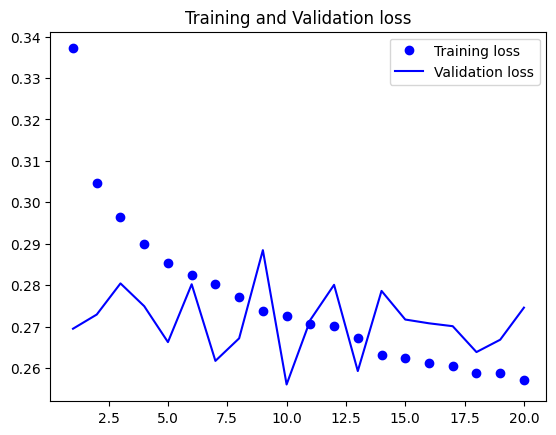

In [16]:
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss)+1)

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and Validation loss')
plt.legend()

plt.show()

Incluir una sola capa RNN incremento el tiempo de entrenamiento a $2'' * epoca$ ($40''$ total). Es mejor que los $2''50''' * epoca$ que habia en la version RNN pero es claramente peor que los $11''' * epoca$ de la version solo CNN. Sin embargo, recordar que CNN+RNN se enfrento al doble de datos por lo que la competencia es un tanto deslean. En una situacion equitativa es probable que los tiempos alcancen un punto mas cerca al intermedio entre los tiempos de RNN puro y CNN puro.

Respecto al rendimiento el error reportado *0.2x* es equivalente peor que la mejor version mostrada por RNN puro (0.26). No obstante, es mucho mejor que lo reportado por CNN puro (0.40). 

La **aproximacion** se coloca en un lugar **intermedio entre aproximaciones RNN y CNN repecto al tiempo de entrenamiento** para problemas donde la ordenacion temporal es relevante. En **rendimiento** es **equivalente a la mejor solucion** obtenida (0,26; **con RNN puro**). 